<a href="https://colab.research.google.com/github/mhasan502/Age_Estimation/blob/Jibon/Age_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing Required Packages

In [1]:
### --- For Connecting Google Colab with Local Host --- ###
# pip install jupyter_http_over_ws
## jupyter serverextension enable --py jupyter_http_over_ws
## jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0

# !pip install tqdm
# !pip install parse
# !pip install kornia
# !pip install autocrop
# !pip install opencv-python
# !pip install -U albumentations

# Importing Required Packages

In [2]:
import os
import sys
import string
import random
import multiprocessing
import numpy as np
from PIL import Image
from tqdm import tqdm
from parse import parse
from autocrop import Cropper
from IPython.display import clear_output

import torch
import torch.nn.functional as F
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Scale, Grayscale, Resize, transforms

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#import warnings
#warnings.filterwarnings("ignore")

# device = torch.device("cpu")
torch.backends.cudnn.benchmark = True
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [3]:
multiprocessing.cpu_count()

4

In [4]:
torch.cuda.device_count()

1

In [5]:
torch.utils.data.get_worker_info()

In [6]:
if torch.cuda.is_available():
  n_workers = torch.cuda.device_count()
else:
  n_workers = multiprocessing.cpu_count()

n_workers

1

In [7]:
!nvidia-smi -L 

GPU 0: NVIDIA GeForce 920MX (UUID: GPU-38bea3f0-6644-d822-3fce-ca69b5e03f7d)


In [8]:
cuda_sum = torch.cuda.memory_summary(torch.device("cuda"), abbreviated=False)
print(cuda_sum)

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |       0 B  |
|       from small pool |       0 B  |       0 B  |       0 B  |       0 B  |
|---------------------------------------------------------------------------|
| Active memory         |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |

In [9]:
#torch.cuda.empty_cache()



---



# Hyperparameters Setting

In [10]:
### --- Hyperparameters --- ###

input_size = 100                                     # 100
num_channels = 3
#hidden_units = 32                                   # 
num_classes = 102                                    # total possible outputs
learning_rate = 0.001                                # 
num_epochs = 5                                      # epoch = 1-forward and backward pass of ALL training samples
batch_size = 102                                     # batch_size = number of training samples in one forward & backward pass
#step_size = 100                                     # number of iterations = number of passes, each pass using [batch_size] number of samples
                                                     # e.g. 100 samples, batch_size=20 --> 100/20 = 5 iterations for 1 epoch
train_size = 0.7
test_size = 0.2



---



# 1. Data Preparation

## a. Transformation

In [11]:
### --- Data Transformation using Albumentations as A --- ###

train_transform = A.Compose([
                       A.Resize(input_size, input_size),
                       A.ToGray(p=1),
                       A.Rotate(limit=10, p=0.3),
                       A.HorizontalFlip(p=0.4),
                       A.OpticalDistortion(p=0.2),
                       A.OneOf([A.Blur(blur_limit=3, p=0.2),
                                A.ColorJitter(p=0.2),
                       ], p=0.2),
                       ToTensorV2()
])

test_transform = A.Compose([
                       A.Resize(input_size, input_size),
                       A.ToGray(p=1),
                       ToTensorV2()
])

## a. Import Data



In [12]:
### --- From Google Drive --- ###

#from google.colab import drive
#drive.mount('/content/gdrive')

In [13]:
# give appropriate location
# directoryAgeDB = '/content/gdrive/MyDrive/Colab Notebooks/AgeDBDataset/AgeDB'

directoryAgeDB = 'AgeDB/'

In [14]:
inside1 = os.listdir(directoryAgeDB)
#inside1 = sorted(os.listdir(directoryAgeDB))

print("AgeDB:")
for i in range(10):
    print(inside1[i])

AgeDB:
0_MariaCallas_35_f.jpg
10000_GlennClose_62_f.jpg
10001_GoldieHawn_23_f.jpg
10002_GoldieHawn_24_f.jpg
10003_GoldieHawn_24_f.jpg
10004_GoldieHawn_27_f.jpg
10005_GoldieHawn_28_f.jpg
10006_GoldieHawn_29_f.jpg
10007_GoldieHawn_30_f.jpg
10008_GoldieHawn_31_f.jpg


In [15]:
def imageList():
  image_list = []
  for i, file in enumerate(sorted(os.listdir(directoryAgeDB))):
    file_labels = parse('{}_{person}_{age}_{gender}.jpg', file)

    if file_labels is None:
        continue

    image = os.path.join(directoryAgeDB, file)
    gender_to_class_id = {
        'm': 0,
        'f': 1
    }
    gender = gender_to_class_id[file_labels['gender']]
    age = int(file_labels['age'])
    image_list.append({
        'image': image,
        'age': age, 
        'gender': gender
    })
  
  return image_list

In [16]:
image_list = imageList()

In [17]:
print(len(image_list))
print(image_list[16487]['image'])
print(image_list[16487]['age'])
print(image_list[16487]['gender'])

16488
AgeDB/9_MariaCallas_30_f.jpg
30
1


In [18]:
train_len = int(len(image_list) * train_size)
test_len = int(len(image_list) * test_size)
validate_len = len(image_list) - (train_len + test_len)

train_image_list, test_image_list, validate_image_list = torch.utils.data.random_split(
    dataset = image_list,
    lengths = [train_len, test_len, validate_len], 
    generator = torch.Generator().manual_seed(5)
)

In [19]:
print(len(train_image_list))
print(len(test_image_list))
print(len(validate_image_list))

11541
3297
1650


In [20]:
def findAge(image_list):
  listofzeros = [0] * 102
  same_age = [i for i in range(0, 102)]
  age_number = dict(zip(same_age, listofzeros))
  sum = 0
  
  for i in range(len(image_list)):
    
    if image_list[i]['age'] in age_number:
      age_number[image_list[i]['age']] += 1
      sum += 1

  print(sum)
  return age_number

In [ ]:
findAge(train_image_list)

In [ ]:
findAge(test_image_list)

In [ ]:
findAge(validate_image_list)

In [24]:
def plotTTage(train_image_list, test_image_list, validate_image_list):  
  #plot 1:
  train_age = findAge(train_image_list).items()
  x1, y1 = zip(*train_age)
  
  #plot 2:
  test_age = findAge(test_image_list).items()
  x2, y2 = zip(*test_age)

  #plot 3:
  val_age = findAge(validate_image_list).items()
  x3, y3 = zip(*val_age)
  
  plt.plot(x1, y1)
  plt.plot(x2, y2)
  plt.plot(x3, y3)
  
  plt.legend(["Train", "Test", "Validation"])
  
  plt.title("Data Distribution")
  plt.xlabel("Age")
  plt.ylabel("Number of Images")
  
  plt.rcParams["figure.figsize"] = (20,10)

  plt.grid()
    
  plt.show()

11541
3297
1650


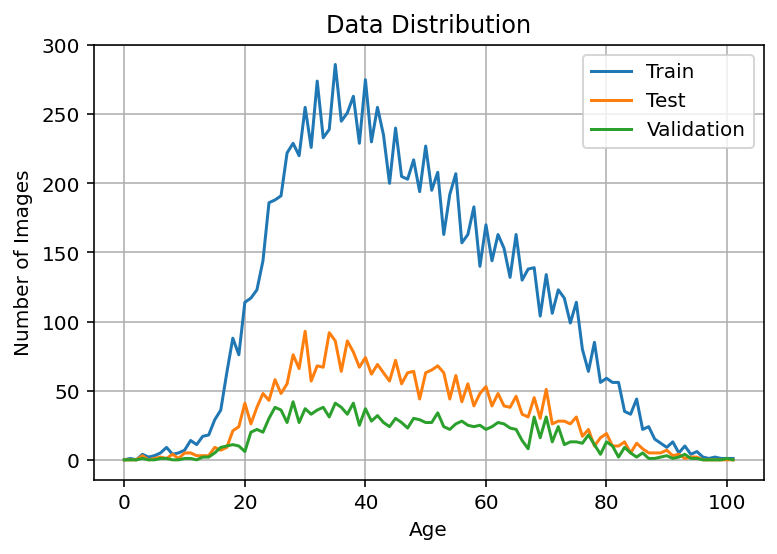

In [25]:
plotTTage(train_image_list, test_image_list, validate_image_list)

## b. DataLoader

### * AgeDB Modified

In [26]:
### --- AgeDB Dataset Class --- ###           {}_{person}_{age}_{gender}.jpg

class AgeDBDataset(Dataset):

# data loading
  def __init__(self, image_list, device, train = True, train_transform=None, test_transform=None, **kwargs):
    
    self.image_list = image_list
    self.device = device
    self.train = train
    self.train_transform = train_transform
    self.test_transform = test_transform
    self.labels = []
    self.images = []
    
    for i in tqdm(range(len(image_list))):
      
      if self.train:
        image = Image.open(self.image_list[i]['image']).convert('RGB')
        image = np.array(image)
        
        for j in range(3):
          
          if j==0:
            augmented_images = self.test_transform(image=image)['image']
            self.images.append(augmented_images)

            age = image_list[i]['age']
            gender = image_list[i]['gender']
            self.labels.append({
                                'age': age, 
                                'gender': gender
            })

          else:
            augmented_images = self.train_transform(image=image)['image']
            self.images.append(augmented_images)

            age = image_list[i]['age']
            gender = image_list[i]['gender']
            self.labels.append({
                                'age': age, 
                                'gender': gender
            })
      

# len(dataset)
  def __len__(self):

    if self.train:
      return len(self.labels)

    else:
      return (len(self.image_list))
    
# dataset[0]
  def __getitem__(self, index):
    
    if torch.is_tensor(index):
      index = index.tolist()

    if self.train:
      image = self.images[index]

      labels = {
              'age': self.labels[index]['age'], 
              'gender': self.labels[index]['gender']
      }
      
      return image.to(self.device), labels

    else:
      image = Image.open(self.image_list[index]['image']).convert('RGB')
      image = np.array(image)
      image = self.test_transform(image=image)['image']
      labels = {
              'age': self.image_list[index]['age'],
              'gender': self.image_list[index]['gender']
      }

      return image.to(self.device), labels


## Dataset Assigned

In [27]:
#### --- For AgeDB Dataset --- ###

trainDataset = AgeDBDataset(
                  image_list = train_image_list,
                  device = device,
                  train = True,
                  train_transform = train_transform,
                  test_transform = test_transform
)

100%|████████████████████████████████████████████████████████████████████████████| 11541/11541 [06:02<00:00, 31.82it/s]


In [28]:
testDataset = AgeDBDataset(
                  image_list = test_image_list,
                  device = device,
                  train = False,
                  train_transform = train_transform,
                  test_transform = test_transform
)

100%|██████████████████████████████████████████████████████████████████████████| 3297/3297 [00:00<00:00, 597813.43it/s]


In [29]:
valDataset = AgeDBDataset(
                  image_list = validate_image_list,
                  device = device,
                  train = False,
                  train_transform = train_transform,
                  test_transform = test_transform
)

100%|██████████████████████████████████████████████████████████████████████████| 1650/1650 [00:00<00:00, 463443.49it/s]


In [30]:
print(len(trainDataset))
print("", len(testDataset))
print("", len(valDataset))

print(len(trainDataset) + len(testDataset) + len(valDataset))

34623
 3297
 1650
39570


## e. Data Splitting 

In [31]:
train_loader = DataLoader(trainDataset, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(testDataset, batch_size=batch_size, shuffle=True)

validation_loader = DataLoader(valDataset, batch_size=batch_size, shuffle=True)

## e. EDA - Exploratory Data Analysis

In [32]:
print(len(train_loader))
print(len(test_loader))
print(len(validation_loader))

340
33
17


In [55]:
print(trainDataset[34622])

(tensor([[[171, 150, 140,  ..., 153, 146, 148],
         [171, 147, 148,  ..., 149, 140, 140],
         [170, 145, 146,  ..., 139, 127, 129],
         ...,
         [ 58,  64,  61,  ..., 122, 150, 171],
         [ 45,  71,  90,  ..., 125, 160, 173],
         [ 37,  52,  70,  ..., 127, 168, 168]],

        [[171, 150, 140,  ..., 153, 146, 148],
         [171, 147, 148,  ..., 149, 140, 140],
         [170, 145, 146,  ..., 139, 127, 129],
         ...,
         [ 58,  64,  61,  ..., 122, 150, 171],
         [ 45,  71,  90,  ..., 125, 160, 173],
         [ 37,  52,  70,  ..., 127, 168, 168]],

        [[171, 150, 140,  ..., 153, 146, 148],
         [171, 147, 148,  ..., 149, 140, 140],
         [170, 145, 146,  ..., 139, 127, 129],
         ...,
         [ 58,  64,  61,  ..., 122, 150, 171],
         [ 45,  71,  90,  ..., 125, 160, 173],
         [ 37,  52,  70,  ..., 127, 168, 168]]], device='cuda:0',
       dtype=torch.uint8), {'age': 45, 'gender': 0})


In [34]:
print(testDataset[1649])

(tensor([[[  2,  70, 250,  ..., 228, 216,   2],
         [  2,  70, 250,  ..., 228, 216,   2],
         [  1,  70, 252,  ..., 227, 214,   3],
         ...,
         [  4,  48, 206,  ..., 225, 204,   1],
         [  4,  51, 210,  ..., 219, 202,   2],
         [  4,  51, 215,  ..., 221, 201,   1]],

        [[  2,  70, 250,  ..., 228, 216,   2],
         [  2,  70, 250,  ..., 228, 216,   2],
         [  1,  70, 252,  ..., 227, 214,   3],
         ...,
         [  4,  48, 206,  ..., 225, 204,   1],
         [  4,  51, 210,  ..., 219, 202,   2],
         [  4,  51, 215,  ..., 221, 201,   1]],

        [[  2,  70, 250,  ..., 228, 216,   2],
         [  2,  70, 250,  ..., 228, 216,   2],
         [  1,  70, 252,  ..., 227, 214,   3],
         ...,
         [  4,  48, 206,  ..., 225, 204,   1],
         [  4,  51, 210,  ..., 219, 202,   2],
         [  4,  51, 215,  ..., 221, 201,   1]]], device='cuda:0',
       dtype=torch.uint8), {'age': 72, 'gender': 0})


In [35]:
def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    if torch.is_tensor(image):      
      image = np.squeeze(image) #you can give axis attribute if you wanna squeeze in specific dimension
      plt.imshow(image.permute(1, 2, 0))
    else:
      plt.imshow(image)

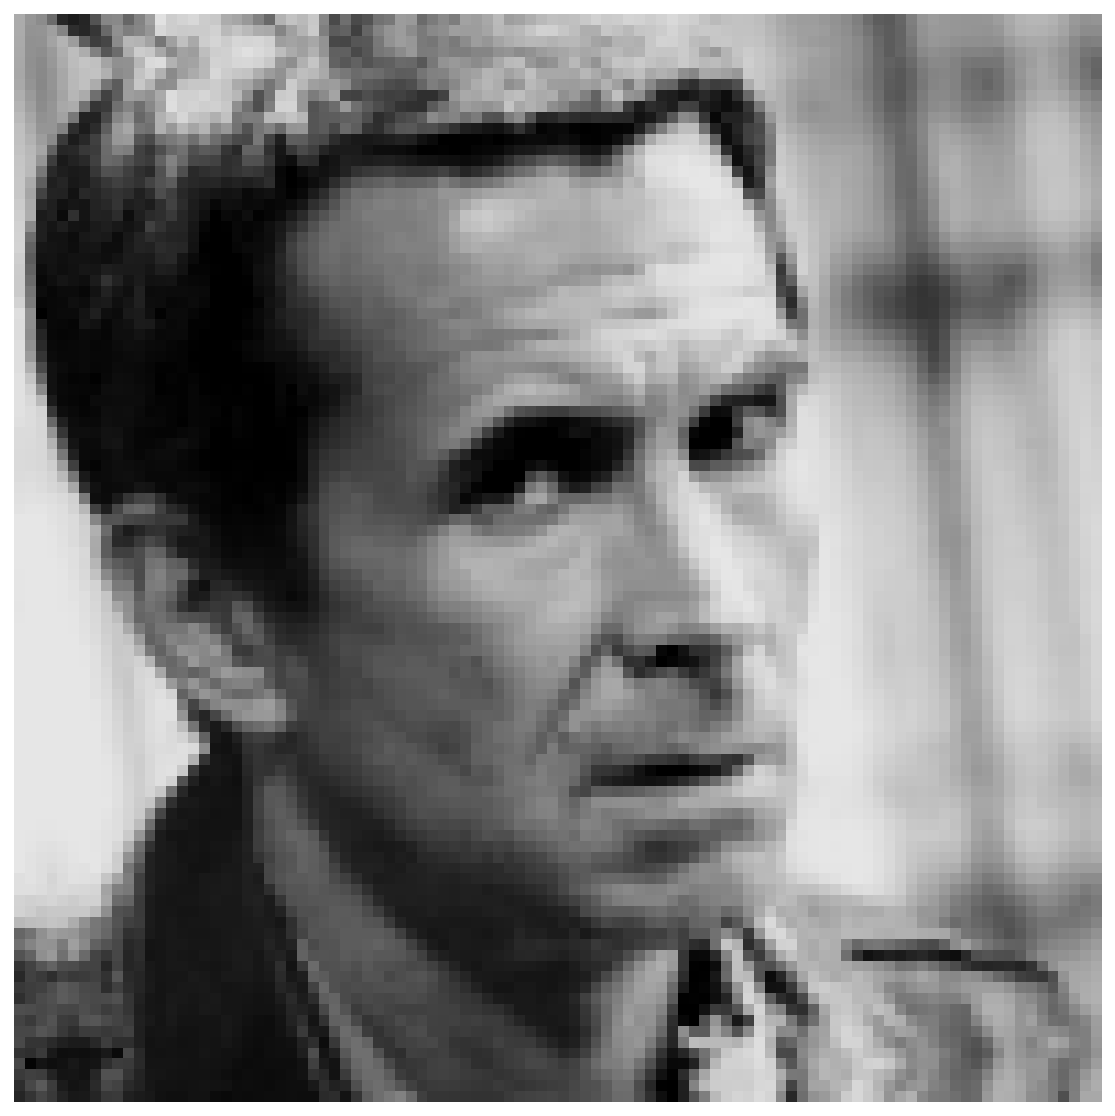

In [36]:
visualize(trainDataset[34622][0].cpu())

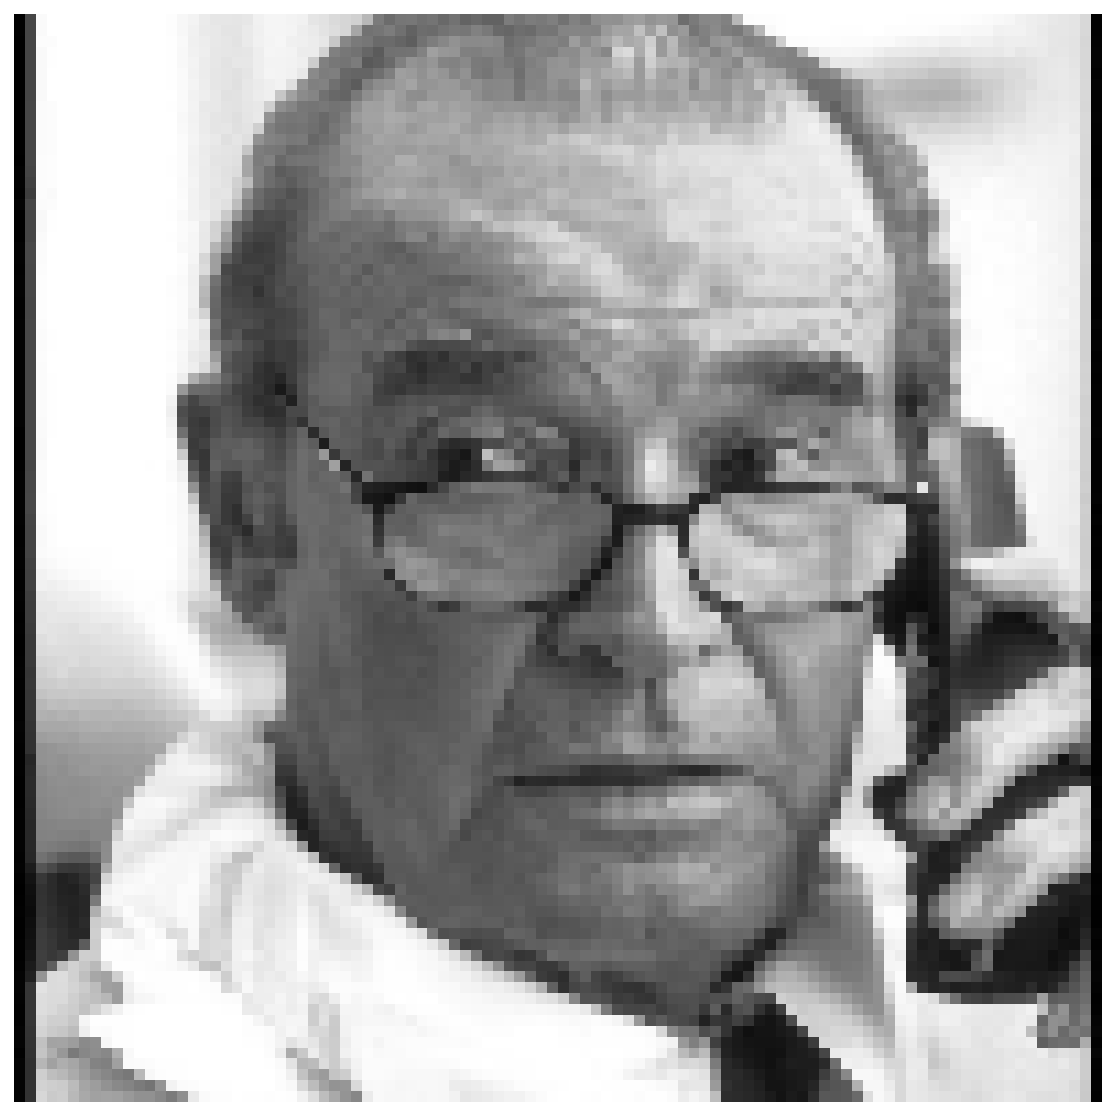

In [37]:
visualize(testDataset[1649][0].cpu())

# 2. Model

## ArcFace CNN

In [38]:
class AngularPenaltySMLoss(nn.Module):

    def __init__(self, in_features, out_features, loss_type='arcface', eps=1e-7, s=None, m=None):
        '''
        Angular Penalty Softmax Loss
        Three 'loss_types' available: ['arcface', 'sphereface', 'cosface']
        These losses are described in the following papers: 
        
        ArcFace: https://arxiv.org/abs/1801.07698
        SphereFace: https://arxiv.org/abs/1704.08063
        CosFace/Ad Margin: https://arxiv.org/abs/1801.05599
        '''
        super(AngularPenaltySMLoss, self).__init__()
        loss_type = loss_type.lower()
        
        assert loss_type in  ['arcface', 'sphereface', 'cosface']
        
        if loss_type == 'arcface':
            self.s = 64.0 if not s else s
            self.m = 0.5 if not m else m
        if loss_type == 'sphereface':
            self.s = 64.0 if not s else s
            self.m = 1.35 if not m else m
        if loss_type == 'cosface':
            self.s = 30.0 if not s else s
            self.m = 0.4 if not m else m
            
        self.loss_type = loss_type
        self.in_features = in_features
        self.out_features = out_features
        self.fc = nn.Linear(in_features, out_features, bias=False).cuda()
        self.eps = eps

    def forward(self, x, labels):
        '''
        input shape (N, in_features)
        '''
        assert len(x) == len(labels)
        assert torch.min(labels) >= 0
        assert torch.max(labels) < self.out_features
        
        for W in self.fc.parameters():
            W = F.normalize(W, p=2, dim=1)

        x = F.normalize(x, p=2, dim=1)

        wf = self.fc(x)
        
        if self.loss_type == 'cosface':
            numerator = self.s * (torch.diagonal(wf.transpose(0, 1)[labels]) - self.m)
        if self.loss_type == 'arcface':
            numerator = self.s * torch.cos(torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)) + self.m)
        if self.loss_type == 'sphereface':
            numerator = self.s * torch.cos(self.m * torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)))

        excl = torch.cat([torch.cat((wf[i, :y], wf[i, y+1:])).unsqueeze(0) for i, y in enumerate(labels)], dim=0)
        denominator = torch.exp(numerator) + torch.sum(torch.exp(self.s * excl), dim=1)
        L = numerator - torch.log(denominator)
        return -torch.mean(L)

## CNN

In [39]:
class Unit(nn.Module):
    def __init__(self,in_channels, out_channels):
        super(Unit,self).__init__()
        
        self.conv = nn.Conv2d(in_channels = in_channels,
                              kernel_size = 3,
                              out_channels = out_channels,
                              stride = 1,
                              padding = 0)
        
        self.bn = nn.BatchNorm2d(num_features = out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self,input):
        output = self.conv(input)
        #output = self.bn(output)
        output = self.relu(output)

        return output

In [40]:
class CNN(nn.Module):                                     #####gradient reversal layer
    def __init__(self, num_classes = 102):
        super(CNN, self).__init__()
        
        
        self.unit1 = Unit(in_channels = 3, out_channels = 4)
        
        self.unit2 = Unit(in_channels = 4, out_channels = 5)
        
        
        self.avgpool = nn.AvgPool2d(kernel_size = 3)
        
        
        self.net = nn.Sequential(self.unit1,
                                 
                                 self.unit2, 
                             
                                
                                 self.avgpool)
        
        self.fc1 = nn.Sequential(nn.Linear(in_features = 5120, out_features = 2000),
                                 nn.LeakyReLU(),
                                 nn.Dropout(0.3),
                                 nn.Linear(in_features = 2000, out_features = num_classes))

    def forward(self, input):
        output = self.net(input)
        output = output.view(-1, 5120)
        output = self.fc1(output)
        return output

In [41]:
class ConvAngularPen(nn.Module):
    def __init__(self, num_classes=102, loss_type='arcface'):
        super(ConvAngularPen, self).__init__()
        self.convlayers = CNN()
        self.adms_loss = AngularPenaltySMLoss(102, num_classes, loss_type=loss_type)

    def forward(self, x, labels=None, embed=False):
        x = self.convlayers(x)
        if embed:
            return x
        L = self.adms_loss(x, labels)
        return L

## Using Model

In [42]:
model = CNN().to(device)

In [43]:
#model =  ConvAngularPen(loss_type='arcface').to(device)

In [44]:
#model = ConvNet().to(device)

In [45]:
#model = ConvBaseline().to(device)

In [46]:
model

CNN(
  (unit1): Unit(
    (conv): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (unit2): Unit(
    (conv): Conv2d(4, 5, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (avgpool): AvgPool2d(kernel_size=3, stride=3, padding=0)
  (net): Sequential(
    (0): Unit(
      (conv): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1))
      (bn): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): LeakyReLU(negative_slope=0.01)
    )
    (1): Unit(
      (conv): Conv2d(4, 5, kernel_size=(3, 3), stride=(1, 1))
      (bn): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): LeakyReLU(negative_slope=0.01)
    )
    (2): AvgPool2d(kernel_size=3, stride=3, padding

# 3. Loss function and Optimizer

In [47]:
### --- FocalLoss --- ###

from kornia.utils.one_hot import one_hot

def focal_loss(
    input: torch.Tensor,
    target: torch.Tensor,
    alpha: float,
    gamma: float = 2.0,
    reduction: str = 'none',
    eps: float = 1e-8,
) -> torch.Tensor:

    if not isinstance(input, torch.Tensor):
        raise TypeError(f"Input type is not a torch.Tensor. Got {type(input)}")

    if not len(input.shape) >= 2:
        raise ValueError(f"Invalid input shape, we expect BxCx*. Got: {input.shape}")

    if input.size(0) != target.size(0):
        raise ValueError(f'Expected input batch_size ({input.size(0)}) to match target batch_size ({target.size(0)}).')

    n = input.size(0)
    out_size = (n,) + input.size()[2:]
    if target.size()[1:] != input.size()[2:]:
        raise ValueError(f'Expected target size {out_size}, got {target.size()}')

    if not input.device == target.device:
        raise ValueError(f"input and target must be in the same device. Got: {input.device} and {target.device}")

    # compute softmax over the classes axis
    input_soft: torch.Tensor = F.softmax(input, dim=1) + eps

    # create the labels one hot tensor
    target_one_hot: torch.Tensor = one_hot(target, num_classes=input.shape[1], device=input.device, dtype=input.dtype)

    # compute the actual focal loss
    weight = torch.pow(-input_soft + 1.0, gamma)

    focal = -alpha * weight * torch.log(input_soft)
    loss_tmp = torch.sum(target_one_hot * focal, dim=1)

    if reduction == 'none':
        loss = loss_tmp
    elif reduction == 'mean':
        loss = torch.mean(loss_tmp)
    elif reduction == 'sum':
        loss = torch.sum(loss_tmp)
    else:
        raise NotImplementedError(f"Invalid reduction mode: {reduction}")
    return loss

class FocalLoss(nn.Module):

    def __init__(self, alpha: float, gamma: float = 2.0, reduction: str = 'none', eps: float = 1e-8) -> None:
        super().__init__()
        self.alpha: float = alpha
        self.gamma: float = gamma
        self.reduction: str = reduction
        self.eps: float = eps

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return focal_loss(input, target, self.alpha, self.gamma, self.reduction, self.eps)



In [48]:
#kwargs = {"alpha": 0.5, "gamma": 2.0, "reduction": 'mean'}
#criterion = FocalLoss(**kwargs)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# Dont use softmax with cross entropy loss

# 4. Training Testing

## a. Training Loop

In [49]:
### --- JUST DO IT --- ###

def train(model, criterion, optimizer, train_loader, num_epochs):

  step_size = len(train_loader)
  maxi = -999999
  mini =  999999
  for epoch in range(num_epochs):
    
    for i, (imgs, labels) in enumerate(train_loader):
      
      X_train_images = imgs.to(device).float()
      y_train_ages = labels['age'].to(device)

    # Forward Pass and Loss
      y_predicted_output_scores = model(X_train_images)
      loss = criterion(y_predicted_output_scores, y_train_ages)

      maxi = max(maxi, loss)
      mini = min(mini, loss)

    # Zeros Gradients
      optimizer.zero_grad()

    # Backward Pass
      loss.backward()

    # Update Weights
      optimizer.step()

      if i % 10 == 0:
        clear_output()
      print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, MIN LOSS: {mini:.4f}, MAX LOSS:{maxi:.4f}')

In [50]:
train(model, criterion, optimizer, train_loader, num_epochs)

EPOCH: 5/5, STEP: 331/340, LOSS: 0.5002
EPOCH: 5/5, STEP: 332/340, LOSS: 0.5693
EPOCH: 5/5, STEP: 333/340, LOSS: 0.3674
EPOCH: 5/5, STEP: 334/340, LOSS: 0.4232
EPOCH: 5/5, STEP: 335/340, LOSS: 0.4592
EPOCH: 5/5, STEP: 336/340, LOSS: 0.3436
EPOCH: 5/5, STEP: 337/340, LOSS: 0.5005
EPOCH: 5/5, STEP: 338/340, LOSS: 0.5192
EPOCH: 5/5, STEP: 339/340, LOSS: 0.3483
EPOCH: 5/5, STEP: 340/340, LOSS: 0.4181
EPOCH: 5/5, STEP: 340/340, MIN LOSS: 0.1318, MAX LOSS:27.6668


## b. Evaluate

In [51]:
def eval(model, test_loader):
  model.to(device).eval()
  step_size = len(test_loader)

  with torch.no_grad():
    correct = total = total_loss = 0
    maxi = -999999
    mini =  999999
    for imgs, labels in tqdm(test_loader):

      X_test_images = imgs.to(device).float()
      y_test_ages = labels['age'].to(device)
     
      y_predicted_output_scores = model(X_test_images)      
      _, predicted = torch.max(y_predicted_output_scores, 1)

      loss = nn.L1Loss()
      loss = loss(predicted.float(), y_test_ages)

      maxi = max(maxi, loss)
      mini = min(mini, loss)

      total_loss += loss
      total += y_test_ages.size(0)
      correct += (predicted == y_test_ages).sum().item()

  model.train()        # turn back training mode on after eval step
  print('\n')
  print(f"Accuracy: {(100 * correct) / total :.4f}%, Correct: {correct}, Total: {total}")
  print(f'Mean Average Error: {total_loss / step_size :.4f}, minimum mae: {mini:.4f}, maximum mae:{maxi:.4f}')

## c. Results

In [52]:
### --- Training Accuracy --- ###

eval(model, train_loader)

100%|████████████████████████████████████████████████████████████████████████████████| 340/340 [00:24<00:00, 14.09it/s]



Accuracy: 98.9516%, Correct: 34260, Total: 34623
Mean Average Error: 0.1380, minimum mae: 0.0000, maximum mae:1.0098


In [53]:
### --- Testing Accuracy on AgeDB --- ###

eval(model, test_loader)

100%|██████████████████████████████████████████████████████████████████████████████████| 33/33 [00:16<00:00,  1.98it/s]



Accuracy: 3.7307%, Correct: 123, Total: 3297
Mean Average Error: 14.1606, minimum mae: 11.8431, maximum mae:18.8485


# Save Model

In [54]:
PATH = 'F:/CSE465 PROJECT/Age_Estimation'
name = ''.join(random.choices(string.ascii_uppercase + string.digits, k = 5)) + '.pth'
print(name)
torch.save(model, os.path.join(PATH, 'CNNmodel.pth'))

BZ0M1.pth
